In [13]:
import xarray as xr
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from microhh.python.plot_microhh_utils import get_local_start

BASE = "/pscratch/sd/m/mpowell/SENSITIVITY_LES_CUMULUS/complexity_20140325"
seed_dirs_no_aerosols = sorted(Path(f"{BASE}/no_aerosols/standard").glob("seed_*/"))
seed_dirs_no_gases = sorted(Path(f"{BASE}/no_gases/standard").glob("seed_*/"))
seed_dirs_prescribed = sorted(Path(f"{BASE}/prescribed_fluxes/standard").glob("seed_*/"))

seed_dirs_no_aerosols_rt = sorted(Path(f"{BASE}/no_aerosols/rt").glob("seed_*/"))
seed_dirs_no_gases_rt = sorted(Path(f"{BASE}/no_gases/rt").glob("seed_*/"))
seed_dirs_prescribed_rt = sorted(Path(f"{BASE}/prescribed_fluxes/rt").glob("seed_*/"))

start = get_local_start(seed_dirs_no_aerosols[0]).replace(tzinfo=None)


In [2]:
ds_no_aerosols = xr.open_mfdataset(
    [str(d / "qlqi_path.xy.nc") for d in seed_dirs_no_aerosols],
    combine='nested', concat_dim='seed', decode_times=False,
)
ds_no_aerosols = ds_no_aerosols.assign_coords(time=start + pd.to_timedelta(ds_no_aerosols.time.values, unit="s"))

ds_no_gases = xr.open_mfdataset(
    [str(d / "qlqi_path.xy.nc") for d in seed_dirs_no_gases],
    combine='nested', concat_dim='seed', decode_times=False,
)
ds_no_gases = ds_no_gases.assign_coords(time=start + pd.to_timedelta(ds_no_gases.time.values, unit="s"))

ds_no_aerosols_rt = xr.open_mfdataset(
    [str(d / "qlqi_path.xy.nc") for d in seed_dirs_no_aerosols_rt],
    combine='nested', concat_dim='seed', decode_times=False,
)
ds_no_aerosols_rt = ds_no_aerosols_rt.assign_coords(time=start + pd.to_timedelta(ds_no_aerosols_rt.time.values, unit="s"))

ds_no_gases_rt = xr.open_mfdataset(
    [str(d / "qlqi_path.xy.nc") for d in seed_dirs_no_gases_rt],
    combine='nested', concat_dim='seed', decode_times=False,
)
ds_no_gases_rt = ds_no_gases_rt.assign_coords(time=start + pd.to_timedelta(ds_no_gases_rt.time.values, unit="s"))

In [3]:
ds_orig = xr.open_mfdataset(
    f"{BASE}/paper_results/20140325_t03/rrtmgp/rndseed*/cabauw.default.0000000.nc",
    combine='nested', concat_dim='seed', group='thermo',
)
ds_orig_root = xr.open_mfdataset(
    f"{BASE}/paper_results/20140325_t03/rrtmgp/rndseed*/cabauw.default.0000000.nc",
    combine='nested', concat_dim='seed', group='/', decode_times=False,
)
# Apply same local start 
ds_orig = ds_orig.assign_coords(
    time=start + pd.to_timedelta(ds_orig_root['time'].values, unit="s")
)

In [4]:
ds_orig_rt = xr.open_mfdataset(
    f"{BASE}/paper_results/20140325_t03/rrtmgp_rt/rndseed*/cabauw.default.0000000.nc",
    combine='nested', concat_dim='seed', group='thermo',
)
ds_orig_root_rt = xr.open_mfdataset(
    f"{BASE}/paper_results/20140325_t03/rrtmgp_rt/rndseed*/cabauw.default.0000000.nc",
    combine='nested', concat_dim='seed', group='/', decode_times=False,
)
# Apply same local start 
ds_orig_rt = ds_orig_rt.assign_coords(
    time=start + pd.to_timedelta(ds_orig_root_rt['time'].values, unit="s")
)

In [5]:
# orig (no x,y dims — std over seeds only)
mean_orig = ds_orig.qlqi_path.mean('seed')
std_orig  = ds_orig.qlqi_path.std('seed')

# no aerosols (spatial mean per seed, then std across seeds)
per_seed_na = ds_no_aerosols.qlqi_path.mean(['x', 'y'])
mean_na = per_seed_na.mean('seed')
std_na  = per_seed_na.std('seed')

# no aerosols no gases
per_seed_ng = ds_no_gases.qlqi_path.mean(['x', 'y'])
mean_ng = per_seed_ng.mean('seed')
std_ng  = per_seed_ng.std('seed')

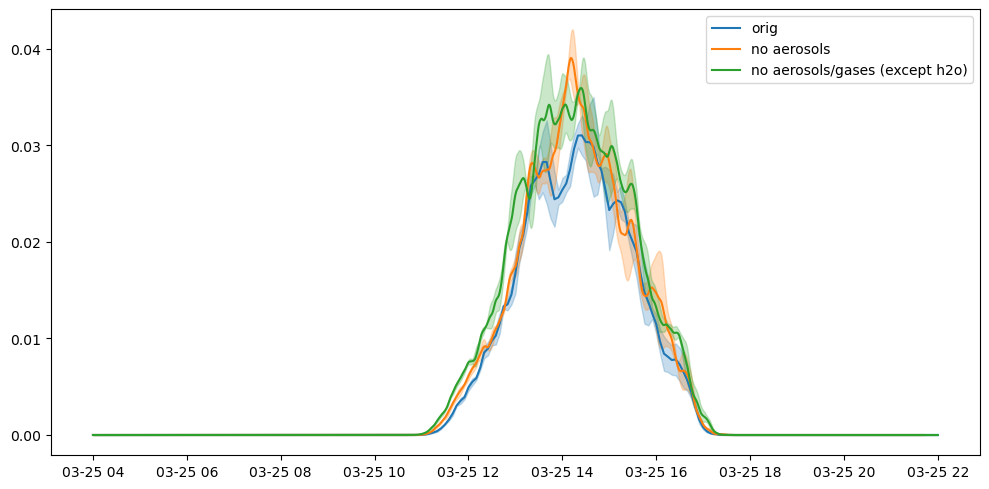

In [7]:
fig, ax = plt.subplots(figsize = (10, 5))
t = mean_orig.time.values
l, = ax.plot(t, mean_orig.values, label='orig')
ax.fill_between(t, (mean_orig - std_orig).values, (mean_orig + std_orig).values,
                alpha=0.25, color=l.get_color())

t = mean_na.time.values
l, = ax.plot(t, mean_na.values, label='no aerosols')
ax.fill_between(t, (mean_na - std_na).values, (mean_na + std_na).values,
                alpha=0.25, color=l.get_color())

t = mean_ng.time.values
l, = ax.plot(t, mean_ng.values, label='no aerosols/gases (except h2o)')
ax.fill_between(t, (mean_ng - std_ng).values, (mean_ng + std_ng).values,
                alpha=0.25, color=l.get_color())
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# orig (no x,y dims — std over seeds only)
mean_orig_rt = ds_orig_rt.qlqi_path.mean('seed')
std_orig_rt  = ds_orig_rt.qlqi_path.std('seed')

# no aerosols (spatial mean per seed, then std across seeds)
per_seed_na_rt = ds_no_aerosols_rt.qlqi_path.mean(['x', 'y'])
mean_na_rt = per_seed_na_rt.mean('seed')
std_na_rt  = per_seed_na_rt.std('seed')

# no aerosols no gases (spatial mean per seed, then std across seeds)
per_seed_ng_rt = ds_no_gases_rt.qlqi_path.mean(['x', 'y'])
mean_ng_rt = per_seed_ng_rt.mean('seed')
std_ng_rt  = per_seed_ng_rt.std('seed')

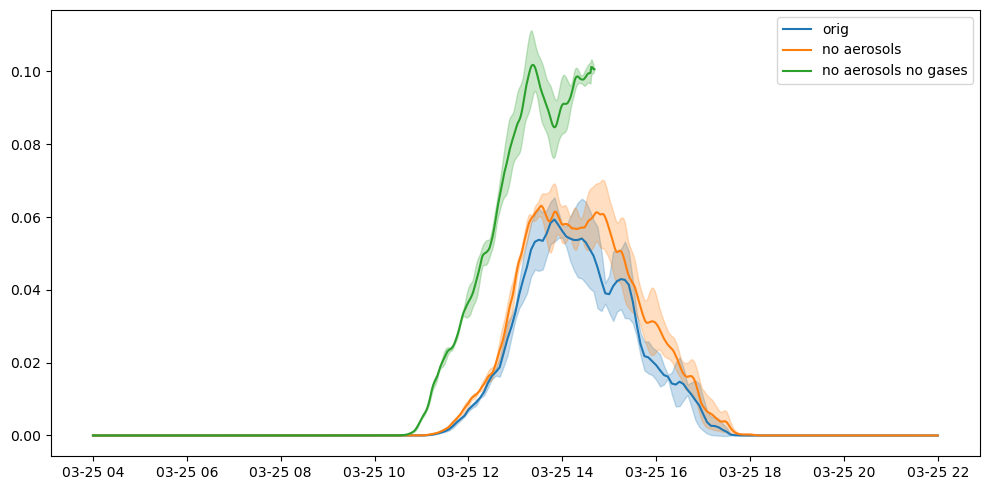

In [9]:
fig, ax = plt.subplots(figsize = (10, 5))
t = mean_orig_rt.time.values
l, = ax.plot(t, mean_orig_rt.values, label='orig')
ax.fill_between(t, (mean_orig_rt - std_orig_rt).values, (mean_orig_rt + std_orig_rt).values,
                alpha=0.25, color=l.get_color())

t = mean_na_rt.time.values
l, = ax.plot(t, mean_na_rt.values, label='no aerosols')
ax.fill_between(t, (mean_na_rt - std_na_rt).values, (mean_na_rt + std_na_rt).values,
                alpha=0.25, color=l.get_color())


t = mean_ng_rt.time.values
l, = ax.plot(t, mean_ng_rt.values, label='no aerosols no gases')
ax.fill_between(t, (mean_ng_rt - std_ng_rt).values, (mean_ng_rt + std_ng_rt).values,
                alpha=0.25, color=l.get_color())

ax.legend()
plt.tight_layout()
plt.show()

In [10]:
std_orig_diff  = (ds_orig_rt.qlqi_path - ds_orig.qlqi_path).std('seed')
std_na_diff = (per_seed_na_rt.sel(time = slice(None, '2014-03-25T21:00')) - per_seed_na.sel(time = slice(None, '2014-03-25T21:00'))).std('seed')
std_ng_diff = (per_seed_ng_rt.sel(time = slice(None, '2014-03-25T21:00')) - per_seed_ng.sel(time = slice(None, '2014-03-25T21:00'))).std('seed')

mean_orig_diff = (mean_orig_rt - mean_orig)
mean_na_diff = (mean_na_rt.sel(time = slice(None, '2014-03-25T21:00')) - mean_na.sel(time = slice(None, '2014-03-25T21:00')))
mean_ng_diff = (mean_ng_rt.sel(time = slice(None, '2014-03-25T21:00')) - mean_ng.sel(time = slice(None, '2014-03-25T21:00')))

In [ ]:
fig, ax = plt.subplots(figsize = (10, 5))
t = mean_orig_rt.time.values
l, = ax.plot(t, mean_orig_diff.values, label='orig')
ax.fill_between(t, (mean_orig_diff - std_orig_diff).values, (mean_orig_diff + std_orig_diff).values,
                alpha=0.25, color=l.get_color())


t = mean_na_rt.sel(time = slice(None, '2014-03-25T21:00')).time.values
l, = ax.plot(t, mean_na_diff.values, label='no aerosols')
ax.fill_between(t, (mean_na_diff - std_na_diff).values, (mean_na_diff + std_na_diff).values,
                alpha=0.25, color=l.get_color())

t = mean_ng_rt.sel(time = slice(None, '2014-03-25T21:00')).time.values
l, = ax.plot(t, mean_ng_diff.values, label='no aerosols no gases')
ax.fill_between(t, (mean_ng_diff - std_ng_diff).values, (mean_ng_diff + std_ng_diff).values,
                alpha=0.25, color=l.get_color())

ax.legend()
plt.tight_layout()
plt.show()

In [16]:
ds_pfluxes = xr.open_mfdataset(
    [str(d / "qlqi_path.xy.nc") for d in seed_dirs_prescribed],
    combine='nested', concat_dim='seed', decode_times=False,
)
ds_pfluxes = ds_pfluxes.assign_coords(time=start + pd.to_timedelta(ds_pfluxes.time.values, unit="s"))

ds_pfluxes_rt = xr.open_mfdataset(
    [str(d / "qlqi_path.xy.nc") for d in seed_dirs_prescribed_rt],
    combine='nested', concat_dim='seed', decode_times=False,
)
ds_pfluxes_rt = ds_pfluxes_rt.assign_coords(time=start + pd.to_timedelta(ds_pfluxes_rt.time.values, unit="s"))


# prescibed fluxes
per_seed_pf = ds_pfluxes.qlqi_path.mean(['x', 'y'])
mean_pf = per_seed_pf.mean('seed')

# prescibed fluxes rt
per_seed_pf_rt = ds_pfluxes_rt.qlqi_path.mean(['x', 'y'])
mean_pf_rt = per_seed_pf_rt.mean('seed')

std_pf_diff = (per_seed_pf_rt.sel(time = slice('2014-03-25T11:00', '2014-03-25T19:00')) - per_seed_pf.sel(time = slice('2014-03-25T11:00', '2014-03-25T19:00'))).std('seed')
mean_pf_diff = (mean_pf_rt.sel(time = slice('2014-03-25T11:00', '2014-03-25T19:00')) - mean_pf.sel(time = slice('2014-03-25T11:00', '2014-03-25T19:00')))


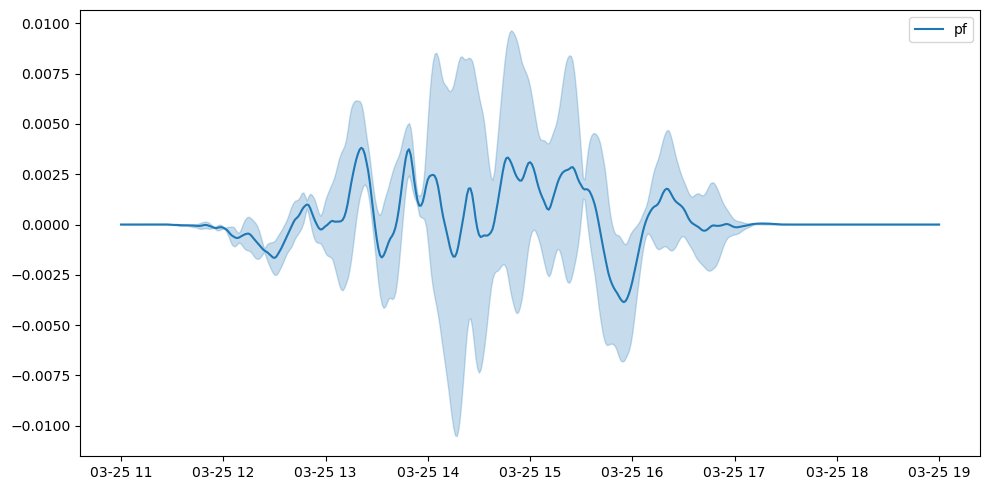

In [18]:
fig, ax = plt.subplots(figsize = (10, 5))
t = mean_pf_rt.sel(time = slice('2014-03-25T11:00', '2014-03-25T19:00')).time.values
l, = ax.plot(t, mean_pf_diff.values, label='pf')
ax.fill_between(t, (mean_pf_diff - std_pf_diff).values, (mean_pf_diff + std_pf_diff).values,
                alpha=0.25, color=l.get_color())

ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

t_start_rt = ds_orig_rt.qlqi_path.time.values[(ds_orig_rt.qlqi_path > 0).argmax(dim='time').values]
t_start_2stream = ds_orig.qlqi_path.time.values[(ds_orig.qlqi_path > 0).argmax(dim='time').values]
t_start = np.min([t_start_rt, t_start_2stream], axis = 0)
 
t_end_rt   = ds_orig_rt.qlqi_path.time.values[(ds_orig_rt.qlqi_path > 0).cumsum(dim='time').argmax(dim='time').values]
t_end_2stream   = ds_orig.qlqi_path.time.values[(ds_orig.qlqi_path > 0).cumsum(dim='time').argmax(dim='time').values]
t_end = np.max([t_end_rt, t_end_2stream], axis = 0)

integrated_list = []
for i, (start, end) in enumerate(zip(t_start, t_end)):
    diff_cloudy = (ds_orig_rt.qlqi_path - ds_orig.qlqi_path).isel(seed = i).sel(time=slice(start, end))
    integrated_list.append(diff_cloudy.integrate('time').values)
print(np.std(integrated_list))
print(np.mean(integrated_list))